In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [4]:
df = pd.read_csv("House_Prices.csv")
df

,area,price
0,2600,550000
1,3000,565000
2,3200,6100000
3,3600,680000
4,4000,725000


In [5]:
df.loc[2, 'price'] = 610000
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [6]:
print(df.price.dtype)

int64


In [7]:
print(df.price.head())

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64


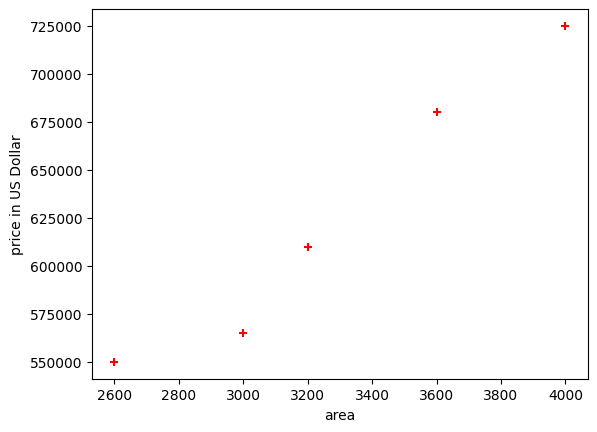

In [8]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price in US Dollar')
plt.scatter(df.area,df.price,color = 'red',marker = '+')
plt.show()

In [9]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']],df.price)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
x = reg.predict(pd.DataFrame([[3300]], columns=['area']))
print(x)

[628715.75342466]


In [11]:
reg.coef_

array([135.78767123])

In [12]:
reg.intercept_

180616.43835616432

In [13]:
m = 135.78767123
x = 3300
b = 180616.43835616432
y = m *x +b
print(y)




628715.7534151643


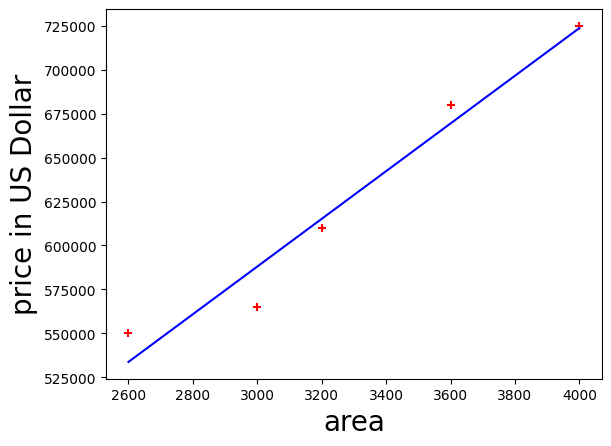

In [14]:
%matplotlib inline
plt.xlabel('area',fontsize=20)
plt.ylabel('price in US Dollar',fontsize = 20)
plt.scatter(df.area,df.price,color = 'red',marker = '+')
plt.plot(df.area,reg.predict(df[['area']]),color = 'blue')
plt.show()

In [15]:
dataArea = pd.read_csv("area_dataset.csv")
dataArea.head(3)

,area
0,4154
1,214
2,4875


In [16]:
predictedPrices = reg.predict(dataArea)

In [17]:
dataArea['prices'] = predictedPrices
dataArea

,area,prices
0,4154,7.446784e+05
1,214,2.096750e+05
2,4875,8.425813e+05
3,1502,3.845695e+05
4,1402,3.709908e+05
5,5013,8.613200e+05
6,9015,1.404742e+06
7,127,1.978615e+05
8,1458,3.785949e+05
9,7958,1.261215e+06


In [18]:
dataArea.to_csv("Predicted_Price.csv",index=False)

In [19]:
import pickle


In [20]:
with open('model_pickle','wb') as file:
    pickle.dump(reg,file)


In [21]:
with open('model_pickle','rb') as f:
    mp = pickle.load(f)

In [22]:
mp.coef_

array([135.78767123])

In [23]:
mp.intercept_

180616.43835616432

In [24]:
mp.predict([[5000]])

c:\Users\Deepak\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([859554.79452055])